In [ ]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive', force_remount=True)

print("AUTO-DETECTING PROJECT LOCATION")

# Try 2 possible locations
possible_paths = [
    '/content/drive/MyDrive/ipynb-project/Road-Damage-Severity-Levels',  # Akun utama
    '/content/drive/MyDrive/Road-Damage-Severity-Levels',                 # Akun lain (shortcut)
]

# Find the correct path
PROJECT_ROOT = None
for path in possible_paths:
    if os.path.exists(path):
        # Double-check: verify processed_dataset folder exists
        if os.path.exists(os.path.join(path, 'processed_dataset')):
            PROJECT_ROOT = path
            print(f"\nFound shortcut/project at: {PROJECT_ROOT}")
            break

if PROJECT_ROOT is None:
    print("\nERROR: Could not find project folder!")
    raise FileNotFoundError("Project folder not found")

# Change to project directory
os.chdir(PROJECT_ROOT)

PROJECT_ROOT = os.getcwd()

print(f"Absolute Working directory: {PROJECT_ROOT}")

Mounted at /content/drive
AUTO-DETECTING PROJECT LOCATION

Found shortcut/project at: /content/drive/MyDrive/ipynb-project/Road-Damage-Severity-Levels
Absolute Working directory: /content/drive/MyDrive/ipynb-project/Road-Damage-Severity-Levels


In [ ]:
!pip install -q ultralytics

from ultralytics import YOLO
import torch

print(f"Ultralytics installed")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 39.5 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics installed
PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [ ]:
import os

def safe_save_path(path):
    """Ensure directory exists"""
    os.makedirs(path, exist_ok=True)
    return path

print("PATH CONFIGURATION LOADED")

if 'PROJECT_ROOT' not in locals():
    raise NameError("PROJECT_ROOT belum didefinisikan! Pastikan kamu sudah me-run Cell 1.")

# 1. DATASET BACA DARI DRIVE & EKSTRAK KE LOKAL
ZIP_PATH = os.path.join(PROJECT_ROOT, 'dataset.zip')
LOCAL_EXTRACT_DIR = '/content/dataset'
PROCESSED_DATASET = LOCAL_EXTRACT_DIR

# 2. TRAINING OUTPUT: SIMPAN DI LOKAL
YOLO_RUNS_DIR = safe_save_path('/content/yolo_runs')

# 3. BACKUP KE DRIVE (Otomatis menyesuaikan dengan path akun yang sedang dipakai)
DRIVE_YOLO_RUNS = safe_save_path(os.path.join(PROJECT_ROOT, 'yolo_runs'))
BEST_MODEL_DIR = safe_save_path(os.path.join(PROJECT_ROOT, 'models'))


print(f"Target Zip      : {ZIP_PATH}")
print(f"Local Dataset   : {LOCAL_EXTRACT_DIR}")
print(f"Local Output    : {YOLO_RUNS_DIR}")
print(f"Drive Backup    : {DRIVE_YOLO_RUNS}")

PATH CONFIGURATION LOADED
Target Zip      : /content/drive/MyDrive/ipynb-project/Road-Damage-Severity-Levels/dataset.zip
Local Dataset   : /content/dataset
Local Output    : /content/yolo_runs
Drive Backup    : /content/drive/MyDrive/ipynb-project/Road-Damage-Severity-Levels/yolo_runs


In [ ]:
import os
import zipfile
import shutil


if not os.path.exists(ZIP_PATH):
    raise FileNotFoundError(f"File {ZIP_PATH} tidak ditemukan!\nPastikan kamu sudah upload dataset.zip ke folder Road-Damage-Severity-Levels di Drive.")

if os.path.exists(LOCAL_EXTRACT_DIR):
    print("Membersihkan sisa dataset lokal sebelumnya...")
    shutil.rmtree(LOCAL_EXTRACT_DIR)

os.makedirs(LOCAL_EXTRACT_DIR, exist_ok=True)

print(f"Mengekstrak {ZIP_PATH}.")

# Proses Ekstrak
with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(LOCAL_EXTRACT_DIR)

LOCAL_DATASET_DIR = LOCAL_EXTRACT_DIR
for root, dirs, files in os.walk(LOCAL_EXTRACT_DIR):
    if 'train' in dirs and 'val' in dirs:
        LOCAL_DATASET_DIR = root
        break

# Set lokasi akhir data.yaml di lokal
DATA_YAML = os.path.join(LOCAL_DATASET_DIR, 'data.yaml')

print(f"Ekstraksi selesai")
print(f"Dataset lokal siap di: {LOCAL_DATASET_DIR}")

Mengekstrak /content/drive/MyDrive/ipynb-project/Road-Damage-Severity-Levels/dataset.zip.
Ekstraksi selesai
Dataset lokal siap di: /content/dataset


In [ ]:
import yaml
import os

print("MEMBUAT DATA.YAML DI PENYIMPANAN LOKAL...")

data_config = {
    'path': LOCAL_DATASET_DIR,
    'train': 'train/images',
    'val': 'val/images',
    'test': 'test/images',
    'nc': 4,
    'names': {
        0: 'Longitudinal Crack',
        1: 'Transverse Crack',
        2: 'Alligator Crack',
        3: 'Pothole'
    }
}

with open(DATA_YAML, 'w') as f:
    yaml.dump(data_config, f, default_flow_style=False, sort_keys=False)

print(f"Fixed data.yaml berhasil dibuat di penyimpanan lokal: {DATA_YAML}")

# Verifikasi isi file
with open(DATA_YAML, 'r') as f:
    print("\nIsi data.yaml sekarang:")
    print(f.read())

MEMBUAT DATA.YAML DI PENYIMPANAN LOKAL...
Fixed data.yaml berhasil dibuat di penyimpanan lokal: /content/dataset/data.yaml

Isi data.yaml sekarang:
path: /content/dataset
train: train/images
val: val/images
test: test/images
nc: 4
names:
  0: Longitudinal Crack
  1: Transverse Crack
  2: Alligator Crack
  3: Pothole



In [ ]:
import glob
import os

print("Verifying local dataset structure...")

splits = ['train', 'val', 'test']
for split in splits:
    img_dir = os.path.join(LOCAL_DATASET_DIR, split, 'images')
    lbl_dir = os.path.join(LOCAL_DATASET_DIR, split, 'labels')

    # Jika folder tidak ada, hitung 0
    n_images = len(glob.glob(os.path.join(img_dir, '*'))) if os.path.exists(img_dir) else 0
    n_labels = len(glob.glob(os.path.join(lbl_dir, '*.txt'))) if os.path.exists(lbl_dir) else 0

    match = 'Match' if n_images == n_labels and n_images > 0 else 'Mismatch/Empty'
    print(f"{match} {split}: {n_images} images, {n_labels} labels")

print("\nDataset verification complete")

Verifying local dataset structure...
Match train: 8690 images, 8690 labels
Match val: 5758 images, 5758 labels
Match test: 5758 images, 5758 labels

Dataset verification complete


In [ ]:
import os
import shutil
import pandas as pd
from ultralytics import YOLO

print("CHECKING FOR CHECKPOINTS & PULLING FROM DRIVE...")

run_name = 'yolov8m_rdd2022'
run_dir_local = os.path.join(YOLO_RUNS_DIR, run_name)
run_dir_drive = os.path.join(DRIVE_YOLO_RUNS, run_name)

checkpoint_local = os.path.join(run_dir_local, 'weights', 'last.pt')
checkpoint_drive = os.path.join(run_dir_drive, 'weights', 'last.pt')

checkpoint_path = None
resume_training = False

# Prioritas 1: Cek apakah di SSD Lokal sudah ada
if os.path.exists(checkpoint_local):
    checkpoint_path = checkpoint_local
    print(f"Found LOCAL checkpoint: {checkpoint_path}")

# Prioritas 2: Kalau di Lokal kosong, tarik dari Drive )
elif os.path.exists(checkpoint_drive):
    checkpoint_path = checkpoint_drive
    print(f"Found DRIVE checkpoint: {checkpoint_drive}")
    print("Menarik (Pulling) sisa history dari Drive ke Lokal...")

    # Copy seluruh folder run (yolov8m_rdd2022) dari Drive ke Lokal
    shutil.copytree(run_dir_drive, run_dir_local, dirs_exist_ok=True)

    checkpoint_path = checkpoint_local # Sekarang path menunjuk ke lokal
    print("Berhasil ditarik ke memori lokal!")

else:
    print("No checkpoint found - will start fresh")


if checkpoint_path:
    # Load info CSV dari lokal
    results_csv = os.path.join(run_dir_local, 'results.csv')
    if os.path.exists(results_csv):
        df = pd.read_csv(results_csv)
        print(f"   Last recorded epoch: {int(df['epoch'].iloc[-1])}")

    model = YOLO(checkpoint_path)
    resume_training = True
else:
    # Kalau benar-benar fresh, pakai yolov8m biasa
    model = YOLO('yolov8m.pt')
    resume_training = False

print(f"\nResume mode: {resume_training}")

CHECKING FOR CHECKPOINTS & PULLING FROM DRIVE...
Found DRIVE checkpoint: /content/drive/MyDrive/ipynb-project/Road-Damage-Severity-Levels/yolo_runs/yolov8m_rdd2022/weights/last.pt
Menarik (Pulling) sisa history dari Drive ke Lokal...
Berhasil ditarik ke memori lokal!
   Last recorded epoch: 94

Resume mode: True


In [ ]:
# Training hyperparameters
TRAINING_CONFIG = {
    'data': DATA_YAML,
    'epochs': 100,
    'batch': 16,
    'imgsz': 640,
    'device': 0,  # GPU 0, use 'cpu' if no GPU
    'workers': 8,
    'patience': 15,  # Early stopping patience
    'save': True,
    'save_period': 5,  # Save checkpoint every 10 epochs
    'project': YOLO_RUNS_DIR,
    'name': 'yolov8m_rdd2022',
    'exist_ok': True,

    # Data augmentation
    'hsv_h': 0.015,
    'hsv_s': 0.7,
    'hsv_v': 0.4,
    'degrees': 10.0,
    'translate': 0.1,
    'scale': 0.5,
    'flipud': 0.5,
    'fliplr': 0.5,
    'mosaic': 1.0,

    # Optimizer
    'optimizer': 'Adam',
    'lr0': 0.001,
    'momentum': 0.937,
    'weight_decay': 0.0005,

    # Loss weights (for class imbalance)
    'cls': 0.5,
    'box': 7.5,
    'dfl': 1.5
}

print("Training configuration:")
for key, value in TRAINING_CONFIG.items():
    print(f"  {key}: {value}")

Training configuration:
  data: /content/dataset/data.yaml
  epochs: 100
  batch: 16
  imgsz: 640
  device: 0
  workers: 8
  patience: 15
  save: True
  save_period: 5
  project: /content/yolo_runs
  name: yolov8m_rdd2022
  exist_ok: True
  hsv_h: 0.015
  hsv_s: 0.7
  hsv_v: 0.4
  degrees: 10.0
  translate: 0.1
  scale: 0.5
  flipud: 0.5
  fliplr: 0.5
  mosaic: 1.0
  optimizer: Adam
  lr0: 0.001
  momentum: 0.937
  weight_decay: 0.0005
  cls: 0.5
  box: 7.5
  dfl: 1.5


In [ ]:
import torch
import os

print("MENGUBAH PATH KE SSD LOKAL")

run_name = 'yolov8m_rdd2022'
checkpoint_path = os.path.join(YOLO_RUNS_DIR, run_name, 'weights', 'last.pt')

if os.path.exists(checkpoint_path):
    print(f"File ditemukan: {checkpoint_path}")
    print("Membuka memori file .pt...")

    # Load model dengan PyTorch
    ckpt = torch.load(checkpoint_path, weights_only=False)

    # Ubah ingatan save_dir-nya ke SSD Lokal
    if 'train_args' in ckpt:
        print("Mengubah target direktori ke SSD Lokal...")
        ckpt['train_args']['project'] = YOLO_RUNS_DIR
        ckpt['train_args']['save_dir'] = os.path.join(YOLO_RUNS_DIR, run_name)

        # Save kembali file .pt nya
        torch.save(ckpt, checkpoint_path)
        print("PROSES SUKSES! last.pt sekarang akan men-save ke Lokal!")
else:
    print("File last.pt tidak ditemukan di Lokal. Pastikan Cell Pulling sudah di-run.")

MENGUBAH PATH KE SSD LOKAL
File ditemukan: /content/yolo_runs/yolov8m_rdd2022/weights/last.pt
Membuka memori file .pt...
Mengubah target direktori ke SSD Lokal...
PROSES SUKSES! last.pt sekarang akan men-save ke Lokal!


In [ ]:
import os
import shutil
from ultralytics import YOLO

def auto_backup(trainer):
    current_epoch = trainer.epoch + 1

    print(f"[AUTO-BACKUP] Menyelamatkan Epoch {current_epoch} ke Google Drive...")

    local_weights = os.path.join(trainer.save_dir, 'weights')
    local_csv = os.path.join(trainer.save_dir, 'results.csv')

    drive_dest = os.path.join(DRIVE_YOLO_RUNS, 'yolov8m_rdd2022')
    drive_weights = os.path.join(drive_dest, 'weights')
    os.makedirs(drive_weights, exist_ok=True)

    try:
        # 1. SELALU COPY last.pt & best.pt SETIAP 1 EPOCH
        for pt_file in ['last.pt', 'best.pt']:
            src = os.path.join(local_weights, pt_file)
            if os.path.exists(src):
                shutil.copy2(src, os.path.join(drive_weights, pt_file))

        # 2. SELALU COPY results.csv SETIAP 1 EPOCH
        if os.path.exists(local_csv):
            shutil.copy2(local_csv, os.path.join(drive_dest, 'results.csv'))

        # 3. COPY epoch.pt
        epoch_pt = os.path.join(local_weights, f'epoch{current_epoch}.pt')
        if os.path.exists(epoch_pt):
            shutil.copy2(epoch_pt, os.path.join(drive_weights, f'epoch{current_epoch}.pt'))

        print(f"[AUTO-BACKUP] Sukses! Data aman di Drive.")
    except Exception as e:
        print(f"❌ [AUTO-BACKUP] Gagal: {e}")
    print("\n")

# 2. SUNTIKKAN FUNGSI KE DALAM MODEL YOLO
model.add_callback("on_fit_epoch_end", auto_backup)

# 3. MULAI TRAINING (TRAIN ATAU RESUME)
if resume_training:
    print(f"Using dataset config: {DATA_YAML}")
    print(f"Resuming training dari Local SSD...\n")
    results = model.train(
        data=DATA_YAML,
        resume=True
    )
else:
    print(f"Starting FRESH training ke Local SSD...\n")
    results = model.train(**TRAINING_CONFIG)

print("\nTRAINING COMPLETE / DIHENTIKAN")

Using dataset config: /content/dataset/data.yaml
Resuming training dari Local SSD...

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/yolo_runs/yolov8m_rdd2022/weights/last.pt, momentum=0.937, mosaic=1.0, multi_scale=0.

In [ ]:
import shutil
import glob
import os

print("MENDORONG (PUSHING) HASIL KE GOOGLE DRIVE SECARA MANUAL")

run_name = 'yolov8m_rdd2022'
local_run = os.path.join(YOLO_RUNS_DIR, run_name)
drive_destination = os.path.join(DRIVE_YOLO_RUNS, run_name)

if os.path.exists(local_run):
    print(" Meng-copy folder yolo_runs dari SSD ke Drive...")
    shutil.copytree(local_run, drive_destination, dirs_exist_ok=True)

    weights = glob.glob(os.path.join(drive_destination, 'weights', '*.pt'))
    print(f"\nBACKUP MANUAL SUKSES!")
    print(f"File checkpoint aman di Drive: {len(weights)} file")
else:
    print("Tidak ada hasil training di lokal untuk di-backup.")

MENDORONG (PUSHING) HASIL KE GOOGLE DRIVE SECARA MANUAL
 Meng-copy folder yolo_runs dari SSD ke Drive...

BACKUP MANUAL SUKSES!
File checkpoint aman di Drive: 72 file


In [ ]:
print("\nEvaluating on validation set...")

# Validation
val_results = model.val(data=DATA_YAML, split='val')

print("\n")
print("VALIDATION RESULTS")
print(f"mAP@0.5: {val_results.box.map50:.4f}")
print(f"mAP@0.5:0.95: {val_results.box.map:.4f}")
print(f"Precision: {val_results.box.mp:.4f}")
print(f"Recall: {val_results.box.mr:.4f}")

# Per-class metrics
print("\nPer-class mAP@0.5:")
class_names = ['Longitudinal', 'Transverse', 'Alligator', 'Pothole']
for idx, (name, map50) in enumerate(zip(class_names, val_results.box.maps)):
    print(f"  {name}: {map50:.4f}")


Evaluating on validation set...
Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,842,076 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 259.3±396.2 MB/s, size: 219.5 KB)
val: Scanning /content/dataset/val/labels.cache... 5758 images, 2265 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 5758/5758 2.0Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 360/360 1.9it/s 3:06
                   all       5758       8177      0.565      0.513      0.519      0.255
    Longitudinal Crack       2011       3890      0.566      0.542      0.531      0.279
      Transverse Crack       1158       1769      0.565      0.515      0.511      0.238
       Alligator Crack       1222       1553      0.591      0.594      0.622      0.325
               Pothole        544        965      0.539      0.401      0.413      0.177
Speed: 1.

In [ ]:
print("\nEvaluating on test set...")

# Test evaluation
test_results = model.val(data=DATA_YAML, split='test')

print("\n")
print("TEST RESULTS")
print(f"mAP@0.5: {test_results.box.map50:.4f}")
print(f"mAP@0.5:0.95: {test_results.box.map:.4f}")
print(f"Precision: {test_results.box.mp:.4f}")
print(f"Recall: {test_results.box.mr:.4f}")


Evaluating on test set...
Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 46.1±41.1 MB/s, size: 387.6 KB)
val: Scanning /content/dataset/test/labels... 3001 images, 1244 backgrounds, 0 corrupt: 52% ━━━━━━────── 3001/5758 326.7it/s 5.2s<8.4srequirements: Ultralytics requirement ['pi-heif'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 2 packages in 270ms
Prepared 1 package in 66ms
Installed 1 package in 5ms
 + pi-heif==1.3.0

requirements: AutoUpdate success ✅ 1.6s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

val: Scanning /content/dataset/test/labels... 5757 images, 2215 backgrounds, 1 corrupt: 100% ━━━━━━━━━━━━ 5758/5758 397.3it/s 14.5s
val: /content/dataset/test/images/Japan_006457.jpg: ignoring corrupt image/label: cannot identify image file '/content/dataset/test/images/Japan_006457.jpg'
val: New cache created: /cont

In [ ]:
# Get best model path
run_dir = os.path.join(YOLO_RUNS_DIR, 'yolov8m_rdd2022')
best_model_path = os.path.join(run_dir, 'weights', 'best.pt')

# Copy to models directory
import shutil
final_model_path = os.path.join(BEST_MODEL_DIR, 'yolov8_best.pt')
shutil.copy2(best_model_path, final_model_path)

print(f"Best model saved to:")
print(f"   {final_model_path}")

# Save metrics summary
metrics_summary = {
    'model': 'YOLOv8m',
    'dataset': 'RDD2022 (processed)',
    'training_epochs': TRAINING_CONFIG['epochs'],
    'validation_results': {
        'mAP@0.5': float(val_results.box.map50),
        'mAP@0.5:0.95': float(val_results.box.map),
        'precision': float(val_results.box.mp),
        'recall': float(val_results.box.mr)
    },
    'test_results': {
        'mAP@0.5': float(test_results.box.map50),
        'mAP@0.5:0.95': float(test_results.box.map),
        'precision': float(test_results.box.mp),
        'recall': float(test_results.box.mr)
    },
    'model_path': final_model_path
}

import json
metrics_path = os.path.join(BEST_MODEL_DIR, 'yolo_metrics.json')
with open(metrics_path, 'w') as f:
    json.dump(metrics_summary, f, indent=2)

print(f"\nMetrics saved to: {metrics_path}")

Best model saved to:
   /content/drive/MyDrive/ipynb-project/Road-Damage-Severity-Levels/models/yolov8_best.pt

Metrics saved to: /content/drive/MyDrive/ipynb-project/Road-Damage-Severity-Levels/models/yolo_metrics.json


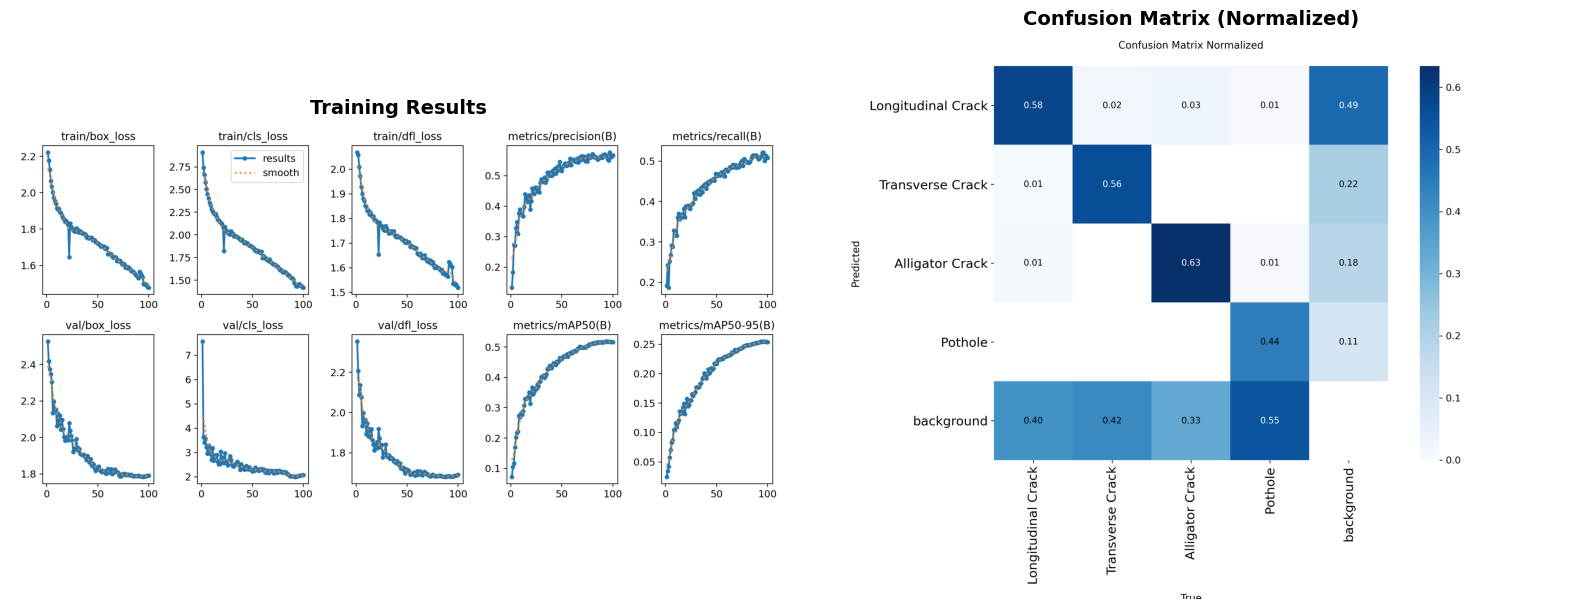

Visualization saved to: /content/drive/MyDrive/ipynb-project/Road-Damage-Severity-Levels/models/training_visualization.png


In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

# Load training plots
results_dir = os.path.join(run_dir, 'results.png')
confusion_matrix = os.path.join(run_dir, 'confusion_matrix_normalized.png')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Results plot
if os.path.exists(results_dir):
    img = Image.open(results_dir)
    axes[0].imshow(img)
    axes[0].set_title('Training Results', fontsize=14, fontweight='bold')
    axes[0].axis('off')

# Confusion matrix
if os.path.exists(confusion_matrix):
    img = Image.open(confusion_matrix)
    axes[1].imshow(img)
    axes[1].set_title('Confusion Matrix (Normalized)', fontsize=14, fontweight='bold')
    axes[1].axis('off')

plt.tight_layout()
viz_path = os.path.join(BEST_MODEL_DIR, 'training_visualization.png')
plt.savefig(viz_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Visualization saved to: {viz_path}")


image 1/1 /content/dataset/test/images/China_MotorBike_000940.jpg: 640x640 1 Pothole, 36.8ms
Speed: 7.7ms preprocess, 36.8ms inference, 14.6ms postprocess per image at shape (1, 3, 640, 640)


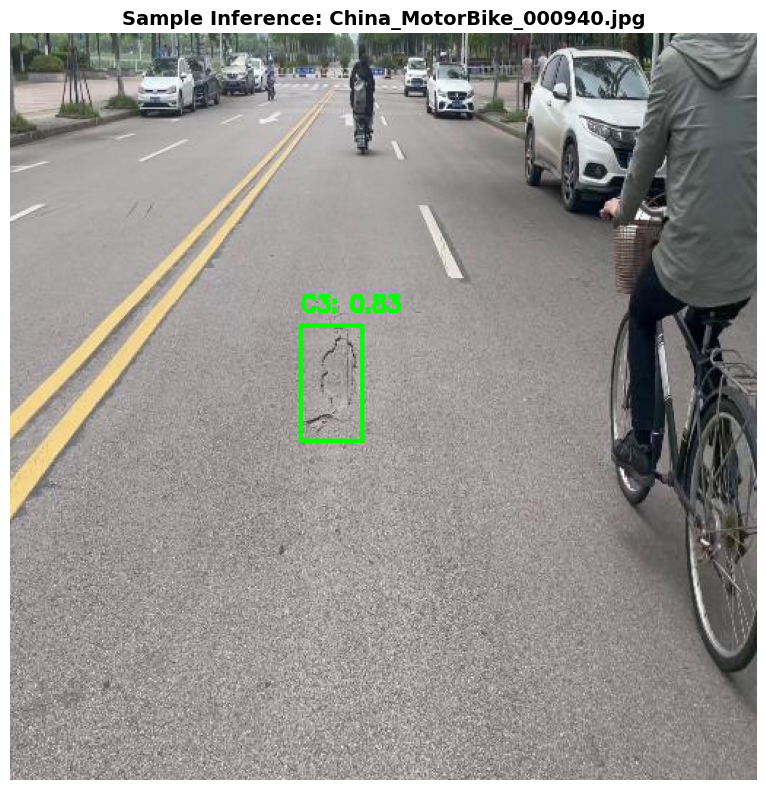

Sample inference saved to: /content/drive/MyDrive/ipynb-project/Road-Damage-Severity-Levels/models/sample_inference.png


In [ ]:
# Test inference on one sample image
import cv2
import numpy as np

test_img_dir = os.path.join(PROCESSED_DATASET, 'test', 'images')
sample_img = os.listdir(test_img_dir)[0]
sample_path = os.path.join(test_img_dir, sample_img)

# Run inference
results_inference = model.predict(source=sample_path, conf=0.25, save=False)

# Visualize
img = cv2.imread(sample_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Draw predictions
for result in results_inference:
    boxes = result.boxes.cpu().numpy()
    for box in boxes:
        x1, y1, x2, y2 = box.xyxy[0].astype(int)
        conf = box.conf[0]
        cls = int(box.cls[0])

        label = f"C{cls}: {conf:.2f}"
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(img, label, (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX,
                   0.5, (0, 255, 0), 2)

plt.figure(figsize=(12, 8))
plt.imshow(img)
plt.title(f'Sample Inference: {sample_img}', fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()

inference_viz_path = os.path.join(BEST_MODEL_DIR, 'sample_inference.png')
plt.savefig(inference_viz_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Sample inference saved to: {inference_viz_path}")

In [ ]:
print("\n")
print("COMPLETE - STAGE 1 YOLO TRAINING")
print("\nGenerated outputs:")
print(f"  {BEST_MODEL_DIR}/")
print("     ├── yolov8_best.pt (Best model weights)")
print("     ├── yolo_metrics.json (Performance metrics)")
print("     ├── training_visualization.png")
print("     └── sample_inference.png")
print(f"\n  {YOLO_RUNS_DIR}/yolov8m_rdd2022/")
print("     └── (Full training logs and checkpoints)")
print("\nPERFORMANCE SUMMARY:")
print(f"  Validation mAP@0.5: {val_results.box.map50:.4f}")
print(f"  Test mAP@0.5: {test_results.box.map50:.4f}")



COMPLETE - STAGE 1 YOLO TRAINING

Generated outputs:
  /content/drive/MyDrive/ipynb-project/Road-Damage-Severity-Levels/models/
     ├── yolov8_best.pt (Best model weights)
     ├── yolo_metrics.json (Performance metrics)
     ├── training_visualization.png
     └── sample_inference.png

  /content/yolo_runs/yolov8m_rdd2022/
     └── (Full training logs and checkpoints)

PERFORMANCE SUMMARY:
  Validation mAP@0.5: 0.5191
  Test mAP@0.5: 0.5304
